# Batch correction test in Harmony

In [1]:
# Load packages
suppressPackageStartupMessages({
    library(ggplot2)
    library(biomaRt)
    library(BiocParallel)
    library(Matrix)
    library(matrixStats)
    library(scater)
    library(reshape2)
    library(knitr)
    library(scran)
    library(harmony)
    library(reticulate)
    library(igraph)
})
    ncores = 4
    mcparam = MulticoreParam(workers = ncores)
    register(mcparam)

options(repr.plot.width=15, repr.plot.height=8)

In [2]:
main = "/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/"
out_dir = paste0(main, '06_batch_correct/')
dir.create(out_dir, showWarnings = FALSE)

source(paste0(main, "core_functions.R"))
load_data(remove_doublets = TRUE, remove_stripped = TRUE)
meta$batch = as.factor(meta$batch)

In [3]:
# Running UMAP from python
source_python(paste0(main, 'UMAP_R_to_py.py'))
run_umap = function(pca_in){
    umap = as.data.frame(umap_redu(pca_in))
    colnames(umap) = c('umap_1', 'umap_2')
    rownames(umap) = meta$cell
    return(umap)    
}

In [4]:
hvgs = getHVGs(sce)
pca = prcomp_irlba(t(logcounts(sce[hvgs,])), n = 50, scale.=TRUE)$x

In [ ]:
umap_theme =  theme(text = element_text(size = 30),
                axis.text.y   = element_blank(),
                axis.text.x   = element_blank(),
                axis.title.y  = element_blank(),
                axis.title.x  = element_blank(),
                axis.ticks = element_blank(),
                legend.position = "none",
                panel.background = element_blank(),
                panel.grid.major = element_blank(), 
                panel.grid.minor = element_blank(),
                panel.border = element_rect(colour = "black", fill=NA, size=1))

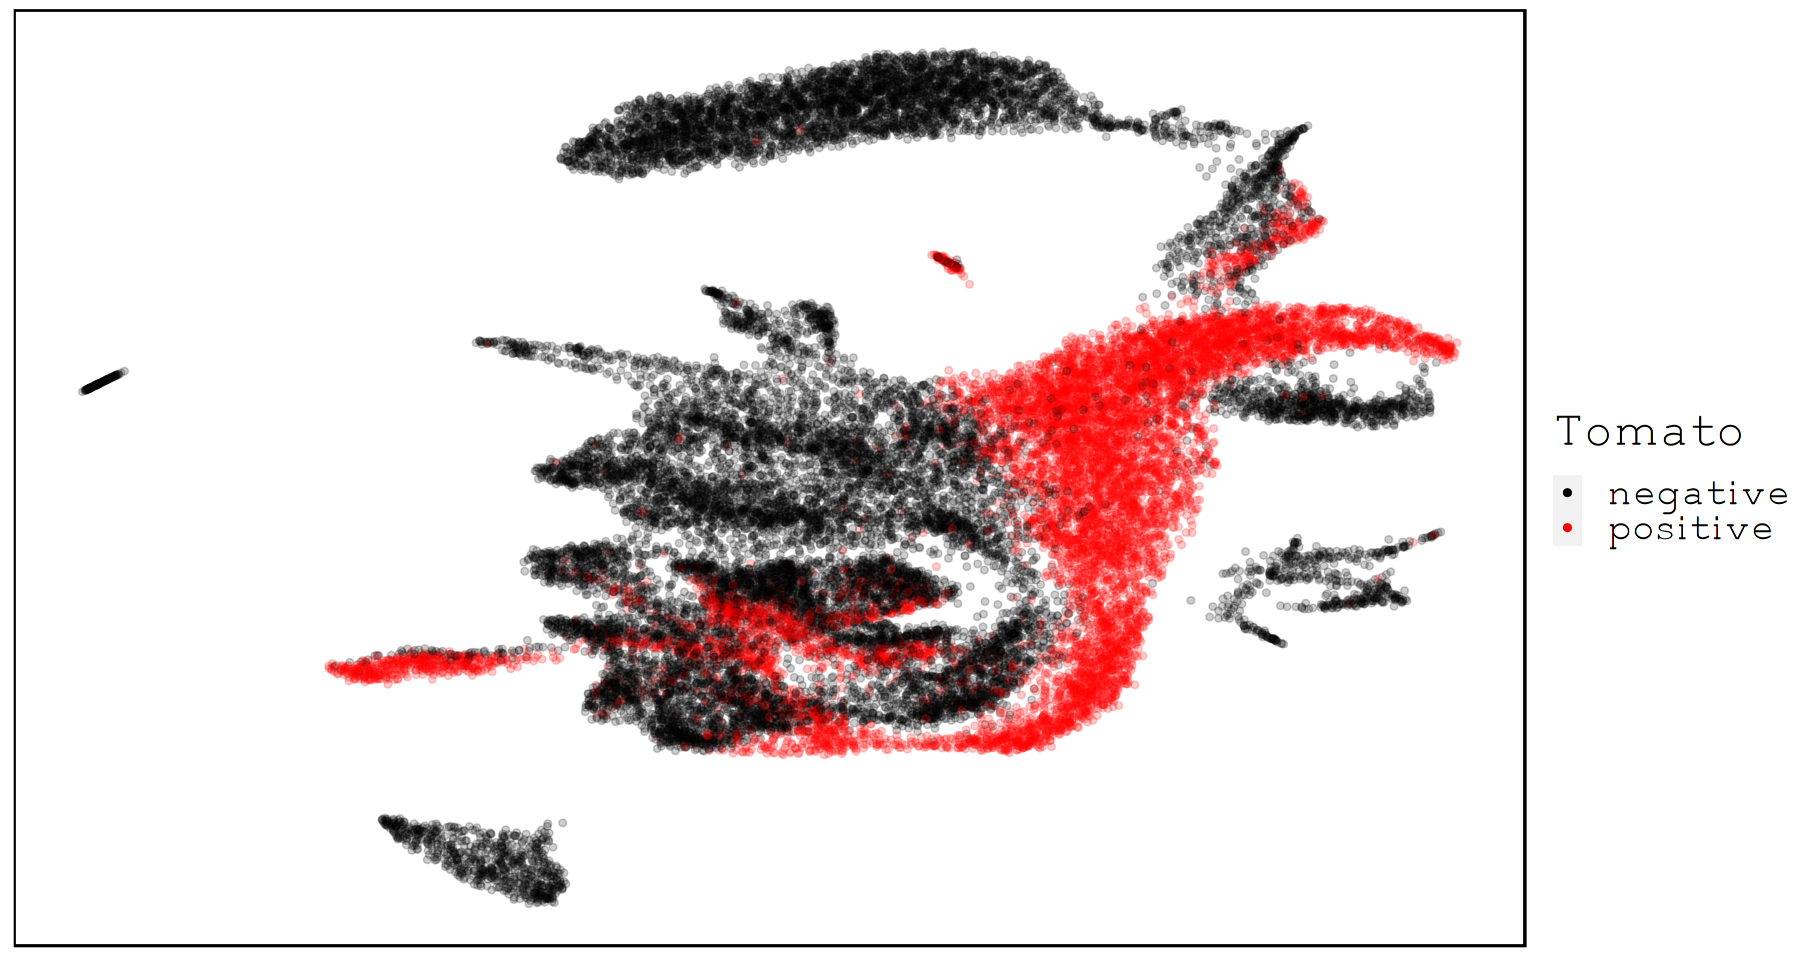

In [9]:
# UMAP before batch correction
umap = run_umap(pca)
ggplot(umap, aes(umap_1, umap_2, col = meta$tdTom)) + 
        geom_point(alpha = 0.2, size = 0.5) + 
        labs(col = "Tomato") + 
        scale_colour_manual(values = c('positive' = 'red', 'negative' = 'black')) +
        ggtitle('Tomato') +
        umap_theme

In [5]:
head(pca)
head(meta)
class(meta$batch)

PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
-1.990932,4.905134,5.515030,1.5107889,1.793520,-2.3712714,-0.7259592,1.683981,-0.6078155,1.28059843,...,0.08452619,-0.3200367,0.9379323,0.31100855,2.38928973,-1.9299715,-2.2529333,0.45946763,0.8894334,-1.74151855
-4.378660,5.347038,-3.797026,1.0372516,-1.169308,2.0782759,4.4906423,-4.593049,3.2005213,1.01113208,...,-0.40161632,-0.7330278,1.7886994,0.37545412,1.10805166,0.6396180,-0.3028006,1.33727301,-1.4406627,-0.06496353
-5.872811,-4.655383,-7.195047,-1.3914080,-2.321253,0.4558935,-5.1595566,2.207662,-7.6814106,-1.82775687,...,-1.75863440,0.3823909,1.3867005,-0.61994691,0.00862804,-0.5797347,-0.3978053,-0.77534490,-0.6984153,-0.46836211
-2.934629,2.293307,5.639041,-1.3798033,-1.132429,-1.7962715,-0.9774222,2.141212,5.3084494,0.02024061,...,-0.58856898,-1.8586493,1.1258535,-0.06130826,-0.30409339,1.5348475,2.0739267,3.08059977,-0.8151764,0.61404256
-4.781453,8.436563,-1.940402,-0.3995596,-2.002120,1.2308571,7.1722839,-3.830300,8.2878179,1.61342928,...,-0.10089406,0.3177964,0.6047610,-0.51257624,-0.45749395,0.8976631,0.1207919,0.02345571,-0.4194732,-0.81916474
-4.986048,3.677308,-8.639310,-1.0200974,-3.350425,1.6913467,4.3523515,-1.169365,1.6716416,-0.15561022,...,0.19519729,-1.5179669,0.9998244,-1.45890807,1.76264619,-0.3493951,-0.5762026,0.86098702,0.5303369,-0.43974329


,cell,barcode,stage,batch,Sample_name,batch_name,tdTom,sample,doub.density,doublet,stripped,index,umap_1,umap_2,louvain_cluster
,<chr>,<chr>,<chr>,<fct>,<chr>,<chr>,<chr>,<int>,<chr>,<lgl>,<lgl>,<int>,<chr>,<chr>,<int>
1,cell_1,AAACCCAGTTCTCTAT,E8.5,3,MLT_G9 Tom+,SLX-20795_SITTA11_HKTG2DRXY,positive,3,13.9251218125,FALSE,FALSE,1,-0.690803468227386,3.69531440734863,11
2,cell_2,AAACGCTAGTGATTCC,E8.5,3,MLT_G9 Tom+,SLX-20795_SITTA11_HKTG2DRXY,positive,3,17.2720353798127,FALSE,FALSE,2,6.81987714767456,10.8029508590698,7
3,cell_3,AAACGCTCATGACTCA,E8.5,3,MLT_G9 Tom+,SLX-20795_SITTA11_HKTG2DRXY,positive,3,10.7818835555556,FALSE,FALSE,3,11.0840997695923,2.86470365524292,9
4,cell_4,AAAGGGCAGTCATGAA,E8.5,3,MLT_G9 Tom+,SLX-20795_SITTA11_HKTG2DRXY,positive,3,11.1007909421488,FALSE,FALSE,4,-2.46467018127441,1.52706468105316,15
6,cell_6,AAAGTGAAGTGTAGAT,E8.5,3,MLT_G9 Tom+,SLX-20795_SITTA11_HKTG2DRXY,positive,3,16.5111062820227,FALSE,FALSE,6,2.88419079780579,10.5994720458984,6
7,cell_7,AACAACCTCCTTATAC,E8.5,3,MLT_G9 Tom+,SLX-20795_SITTA11_HKTG2DRXY,positive,3,0,FALSE,FALSE,7,7.03981971740723,7.38834571838379,10


[1] "factor"

In [6]:
# Run batch correction
harmony_embeddings <- harmony::HarmonyMatrix(
    pca, meta, 'batch', do_pca = FALSE, verbose=FALSE
)

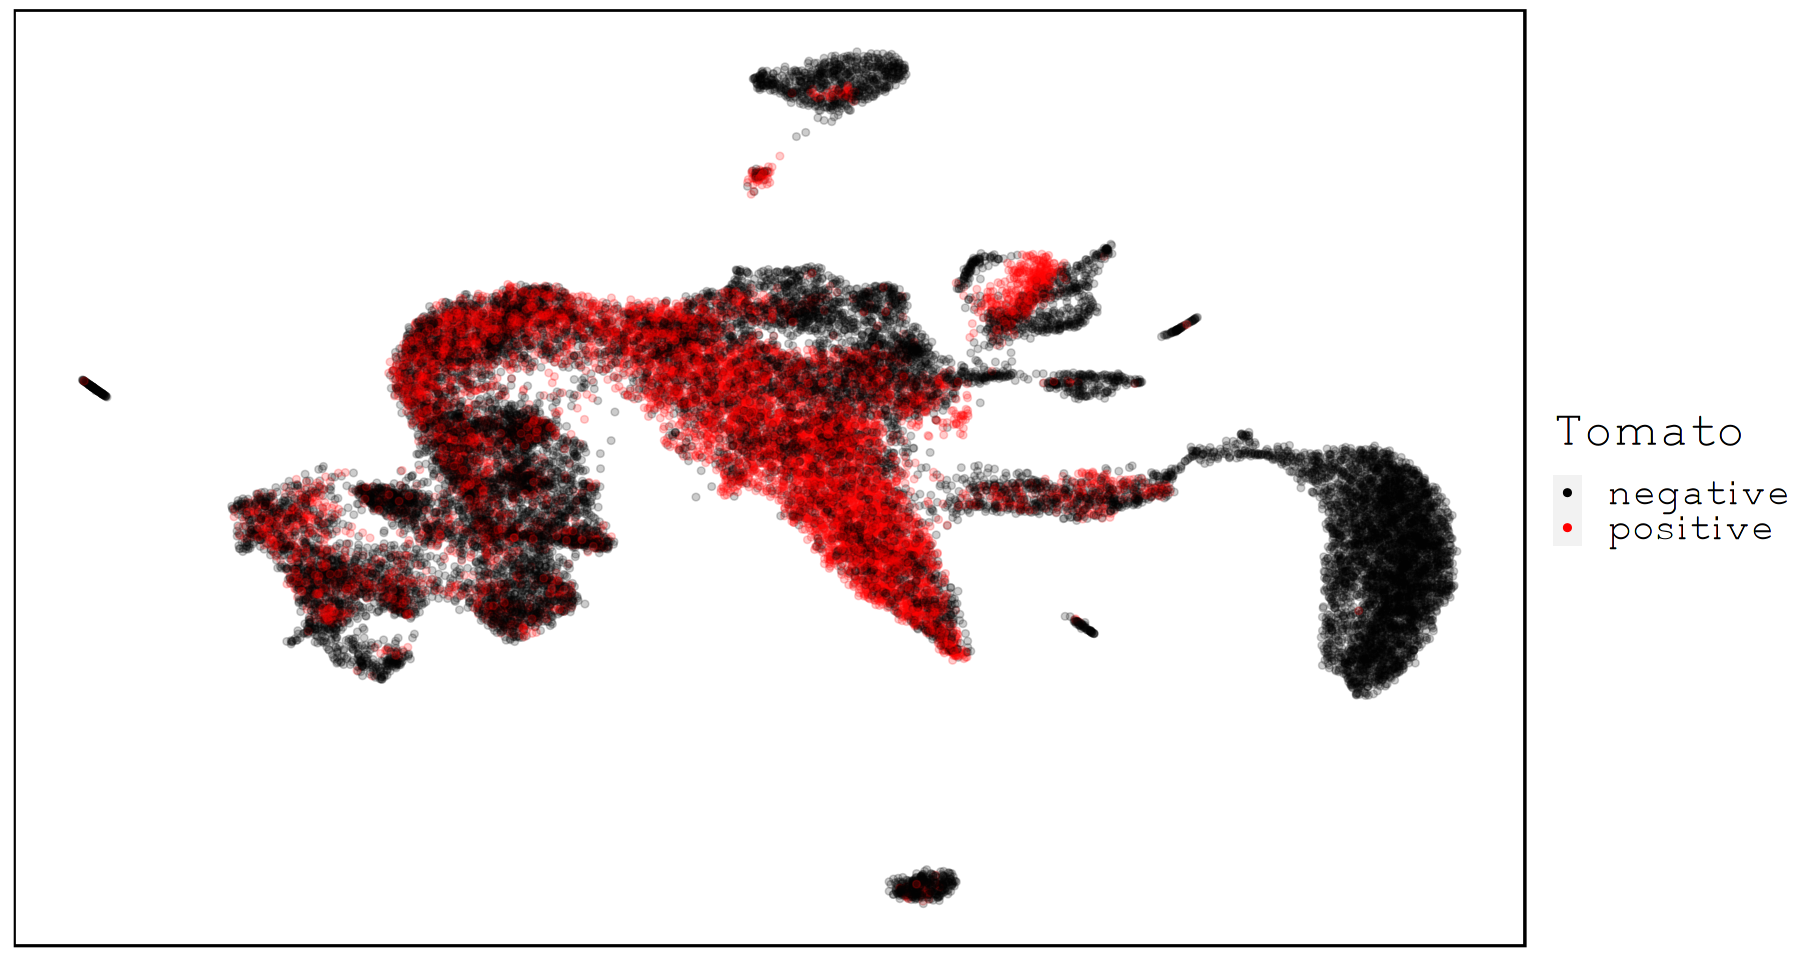

In [10]:
# UMAP after batch correction
umap_corr = run_umap(harmony_embeddings)
p1 = ggplot(umap_corr, aes(umap_1, umap_2, col = meta$tdTom)) + 
        geom_point(alpha = 0.2, size = 0.5) + 
        labs(col = "Tomato") + 
        scale_colour_manual(values = c('positive' = 'red', 'negative' = 'black')) +
        ggtitle('Tomato') +
        umap_theme
p1

In [ ]:
p2 = ggplot(meta, aes(umap_1, umap_2, col = as.factor(sample))) + 
        geom_point(alpha = 0.2, size = 0.5) + 
        ggtitle('Samples') +
        umap_theme
p2

In [ ]:
ggsave(paste0(out_dir, 'UMAPs_tomato_samples.png'), 
       grid.arrange(p1, p2, ncol = 2),
       device = 'png',
       width = 12,
       height = 5,
       dpi = 300)

In [45]:
# Save metadata & corrected PCs
meta = read.csv2(paste0(main, '05_doublet_detection/meta.tab'), sep='\t')
umap_corr$cell = row.names(umap_corr)
meta$index = seq(1:nrow(meta))
meta = merge(meta, umap_corr, by='cell', all=TRUE)
meta = meta[order(meta$index),]

In [46]:
head(meta)

,cell,barcode,stage,batch,Sample_name,batch_name,tdTom,sample,doub.density,doublet,stripped,index,umap_1,umap_2
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<lgl>,<lgl>,<int>,<dbl>,<dbl>
1,cell_1,AAACCCAGTTCTCTAT,E8.5,3,MLT_G9 Tom+,SLX-20795_SITTA11_HKTG2DRXY,positive,3,13.9251218125,FALSE,FALSE,1,-0.6908035,3.695314
11112,cell_2,AAACGCTAGTGATTCC,E8.5,3,MLT_G9 Tom+,SLX-20795_SITTA11_HKTG2DRXY,positive,3,17.2720353798127,FALSE,FALSE,2,6.8198771,10.802951
22223,cell_3,AAACGCTCATGACTCA,E8.5,3,MLT_G9 Tom+,SLX-20795_SITTA11_HKTG2DRXY,positive,3,10.7818835555556,FALSE,FALSE,3,11.0840998,2.864704
23506,cell_4,AAAGGGCAGTCATGAA,E8.5,3,MLT_G9 Tom+,SLX-20795_SITTA11_HKTG2DRXY,positive,3,11.1007909421488,FALSE,FALSE,4,-2.4646702,1.527065
24617,cell_5,AAAGGTAAGCCTGCCA,E8.5,3,MLT_G9 Tom+,SLX-20795_SITTA11_HKTG2DRXY,positive,3,22.1656470868014,TRUE,FALSE,5,NA,NA
25728,cell_6,AAAGTGAAGTGTAGAT,E8.5,3,MLT_G9 Tom+,SLX-20795_SITTA11_HKTG2DRXY,positive,3,16.5111062820227,FALSE,FALSE,6,2.8841908,10.599472


In [14]:
# Add clusters to metadata
graph = buildSNNGraph(t(harmony_embeddings))
clusters = cluster_louvain(graph)
vec = as.numeric(membership(clusters))

In [29]:
length(vec)
nrow(meta)

[1] 27986

[1] 30171

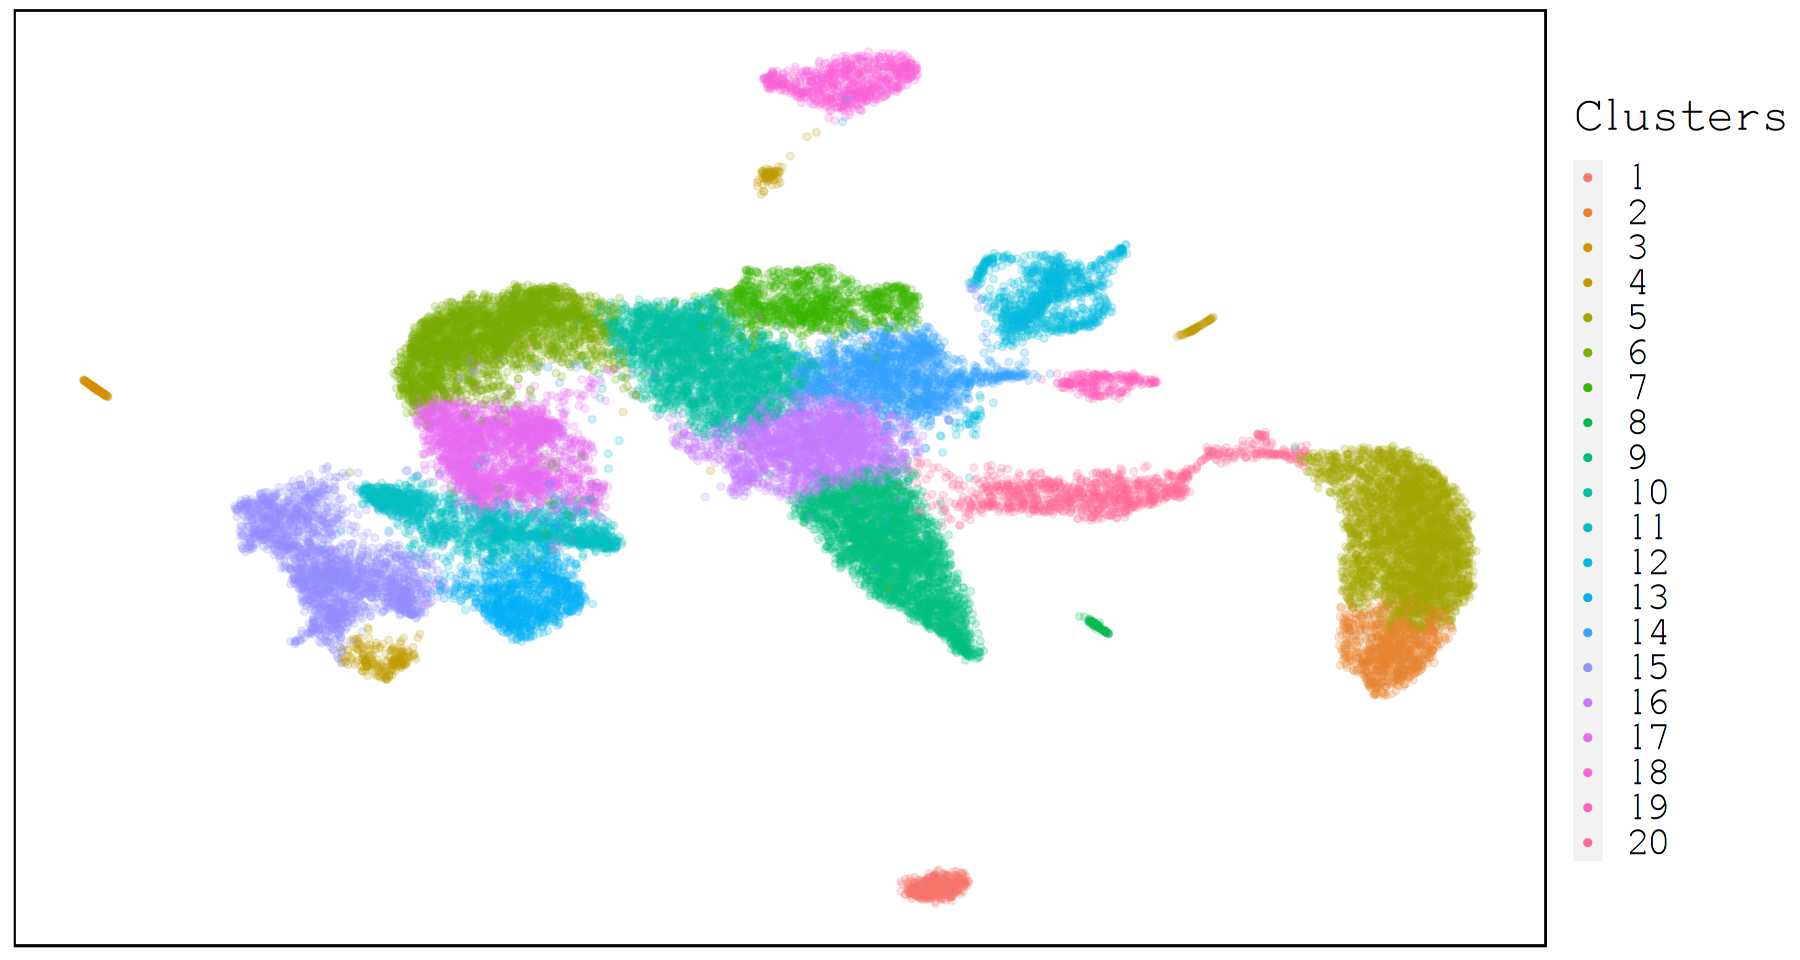

In [24]:
p2 = ggplot(umap_corr, aes(umap_1, umap_2, col = as.factor(vec))) + 
        geom_point(alpha = 0.2) + 
        geom_point(alpha = 0.2, size = 0.5) + 
        ggtitle('Louvain cluster') +
        umap_theme
p2

In [47]:
cluster_df = data.frame('cell' = colnames(sce), 'louvain_cluster' = vec)
meta = merge(meta, cluster_df, by='cell', all=TRUE)
meta = meta[order(meta$index),]

In [49]:
head(meta,2)
nrow(meta)

,cell,barcode,stage,batch,Sample_name,batch_name,tdTom,sample,doub.density,doublet,stripped,index,umap_1,umap_2,louvain_cluster
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<lgl>,<lgl>,<int>,<dbl>,<dbl>,<dbl>
1,cell_1,AAACCCAGTTCTCTAT,E8.5,3,MLT_G9 Tom+,SLX-20795_SITTA11_HKTG2DRXY,positive,3,13.9251218125,FALSE,FALSE,1,-0.6908035,3.695314,11
11112,cell_2,AAACGCTAGTGATTCC,E8.5,3,MLT_G9 Tom+,SLX-20795_SITTA11_HKTG2DRXY,positive,3,17.2720353798127,FALSE,FALSE,2,6.8198771,10.802951,7


[1] 30171

In [50]:
write.table(meta, file = paste0(main, 'meta.tab'), sep = "\t", quote = FALSE, row.names = FALSE, col.names = TRUE)

write.csv2(harmony_embeddings, file = paste0(out_dir, 'PCA_corrected.csv'), row.names = FALSE)

In [88]:
head(data[,2])

[1] 0 0 0 0 0 0

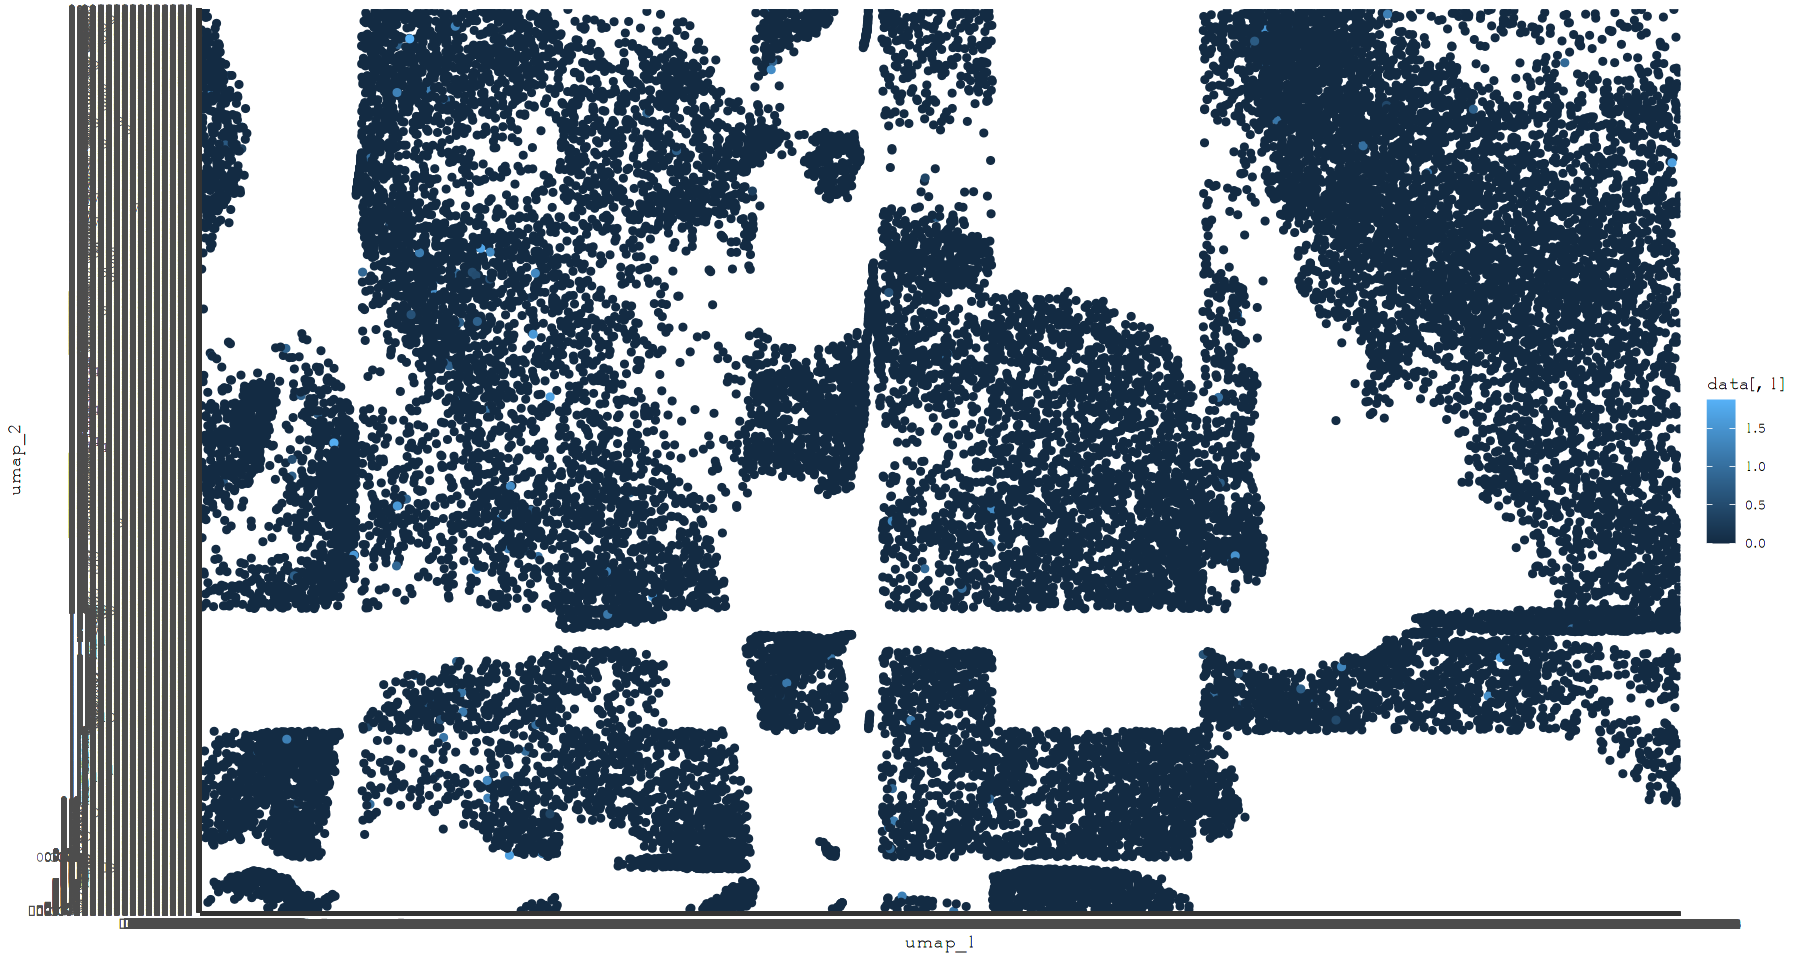

In [96]:
#data = as.data.frame(t(logcounts(sce[1:2])))
#ggplot(meta, aes(umap_1, umap_2, col=data[,1])) + geom_point()

In [101]:
meta$umap_1 = as.numeric(meta$umap_1)
meta$umap_2 = as.numeric(meta$umap_2)

In [111]:
head(data)

,ENSMUSG00000051951,ENSMUSG00000089699
,<dbl>,<dbl>
cell_1,0,0
cell_2,0,0
cell_3,0,0
cell_4,0,0
cell_6,0,0
cell_7,0,0


In [120]:
rownames(sce[1,])

[1] "ENSMUSG00000051951"

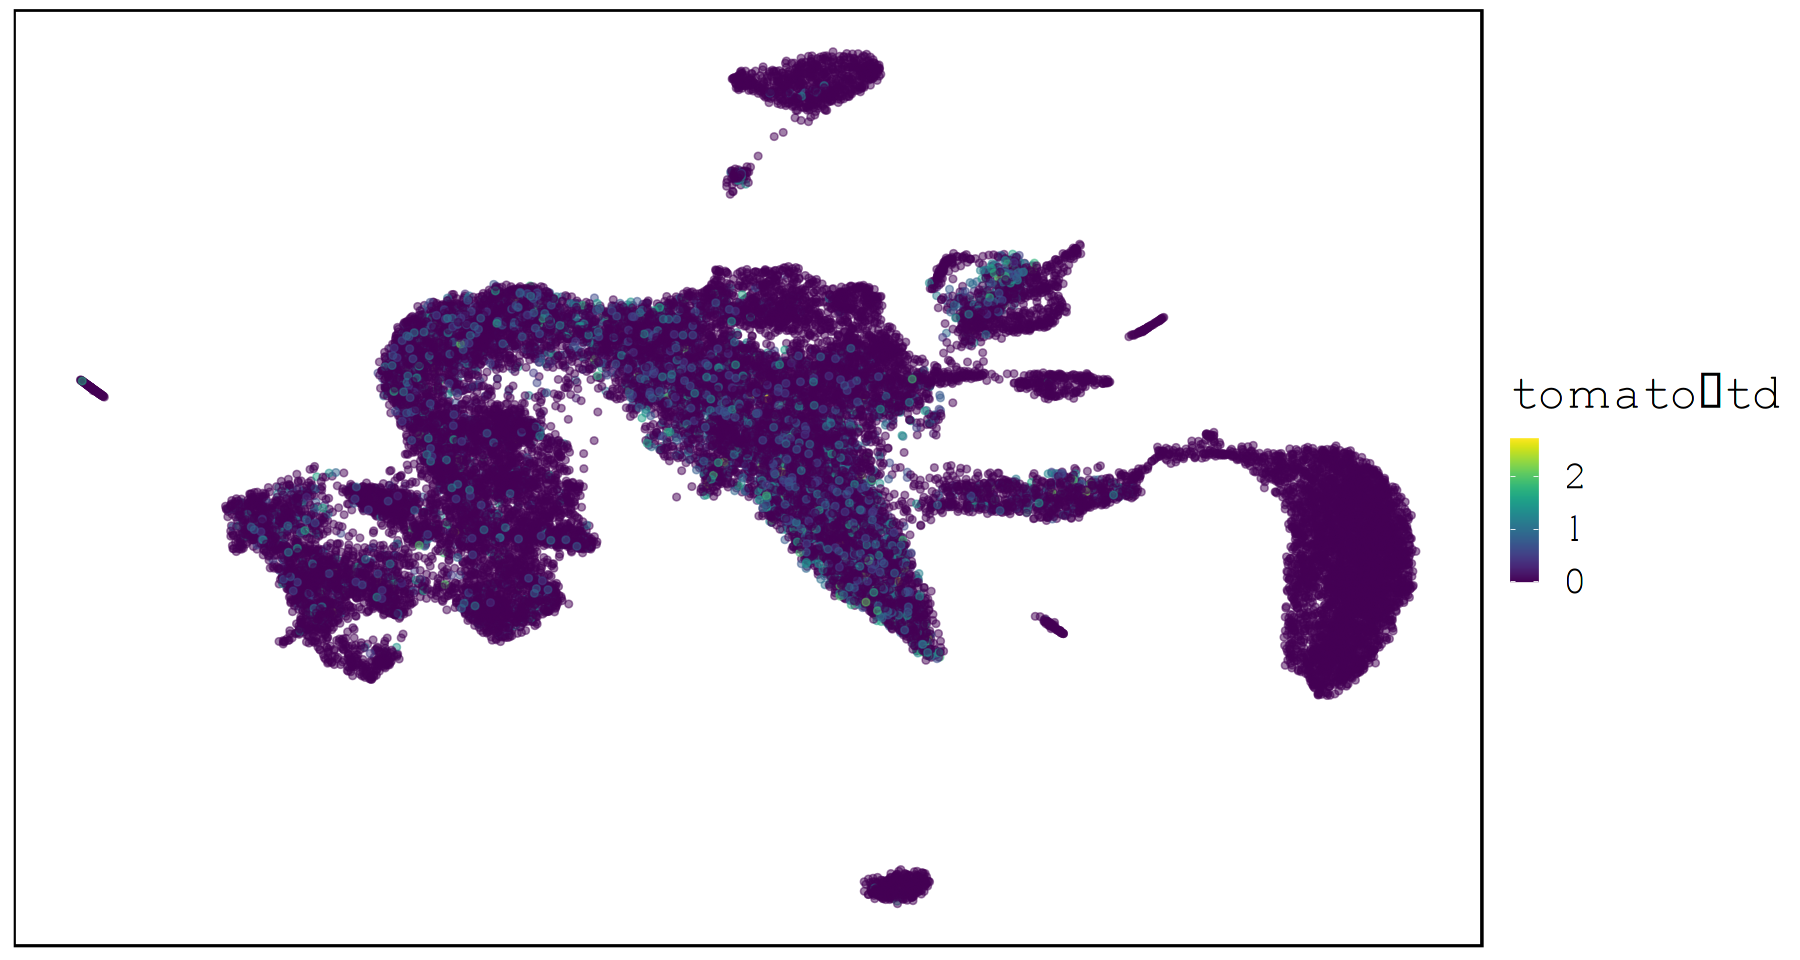

In [123]:
i = nrow(sce)
ggplot(meta, aes(umap_1, umap_2, col=as.vector(logcounts(sce[i,])))) + 
    geom_point(alpha=0.5) + 
    scale_color_viridis(name = rownames(sce[i,])) +
    theme(text = element_text(size = 30),
            axis.text.y   = element_blank(),
            axis.text.x   = element_blank(),
            axis.title.y  = element_blank(),
            axis.title.x  = element_blank(),
            axis.ticks = element_blank(),
            #legend.position = "none",
            panel.background = element_blank(),
            panel.grid.major = element_blank(), 
            panel.grid.minor = element_blank(),
            panel.border = element_rect(colour = "black", fill=NA, size=1))

In [1]:
sessionInfo()

R version 4.0.3 (2020-10-10)
Platform: x86_64-pc-linux-gnu (64-bit)
Running under: Manjaro Linux

Matrix products: default
BLAS:   /usr/local/lib64/R/lib/libRblas.so
LAPACK: /usr/local/lib64/R/lib/libRlapack.so

locale:
 [1] LC_CTYPE=en_GB.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_GB.UTF-8        LC_COLLATE=en_GB.UTF-8    
 [5] LC_MONETARY=en_GB.UTF-8    LC_MESSAGES=en_GB.UTF-8   
 [7] LC_PAPER=en_GB.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_GB.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

loaded via a namespace (and not attached):
 [1] getPass_0.2-2       digest_0.6.27       crayon_1.4.1       
 [4] IRdisplay_0.7.0     repr_1.1.0          lifecycle_0.2.0    
 [7] jsonlite_1.7.2      evaluate_0.14       pillar_1.4.7       
[10] rlang_0.4.10        uuid_0.1-4          ellipsis_0.3.1     
[13] IRkernel_1.1.1.900